# Point 3, Decision Support, Forecast Adaptive Policy

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation](#sec2)
- [3. The Cost Model](#sec3)
- [4. The Forecast Adaptive Policy](#sec4)
- [5. Checking Against Real Outcomes](#sec5)
- [6. Fairness Check](#sec6)
- [7. How Much Would These Numbers Move](#sec7)
- [8. Saving The Standardized Result](#sec8)
- [9. How Sensitive Is This To The Exact Cost Ratio](#sec9)
- [10. Takeaways](#sec10)

<a id="sec1"></a>

## 1. The Problem And This Approach

A memory clinic cannot bring every patient back for a full workup every week, that would be far too expensive, but it also cannot wait years between visits, because a patient can quietly cross from a healthy diagnosis into a worse one between two visits, and nobody notices until the damage is already done. Point 3 turns a risk measure into an actual scheduling decision, how many months should pass before this patient is checked again.

This notebook is the fourth of four interval choosing policies now covered in this folder, fixed, snapshot adaptive, trajectory adaptive, and this one, forecast adaptive, each reading more of what is already known about a patient than the last, from nothing, to today's own risk, to that risk's own recent trend, to a genuine forecast of it. The first three all price a candidate interval the same way, one risk number, RISK_SCORE, scaled by interval length against REFERENCE_INTERVAL_MONTHS to approximate what that risk would be over an interval other than the one it was really measured at, a reasonable approximation when only one number is available at all. This notebook instead reads results/hazard_model/hazard_estimates.csv's own CONVERSION_PROB_3M, CONVERSION_PROB_6M, and CONVERSION_PROB_12M columns directly, one real forecast probability per candidate interval already, computed by hazard_survival_model.ipynb following 05 pm, lesson 6's own persistence approximation, so choosing and pricing an interval here never needs to stretch one snapshot number to stand in for every horizon at once.

Two new pieces in util/decision_util.py make this possible, recommend_interval_forecast, a fourth policy alongside the three above, and ConversionCostModel.cost_from_forecast, a second cost method alongside .cost. Both are described in full in their own docstrings, the short version is that neither ever rescales by interval length the way the three older policies do, a forecast already anchored at its own horizon should not be rescaled a second time, doing so would price the same horizon twice over.

Worth being direct about what this notebook does not attempt. Choosing the cheapest candidate from a small fixed menu given a prediction is still Predict then Optimize, as 08 dfl tf, lesson 1 frames it, not Decision Focused Learning, where the model itself would be trained end to end against the downstream cost. ADNI records no historical interval decisions or their real cost outcomes to train a genuine decision policy against in the first place, only real diagnoses at whatever intervals the study itself happened to schedule, so a full DFL objective has nothing to learn from here regardless of which prediction feeds it, a richer forecast is the honest improvement available, not a fitted policy.

All interval notebooks in this folder, plus the risk factor notebooks, the fairness notebook, and the pipeline notebook that build on the same idea, are self sufficient, each one loads the data, fits or defines its own policy, and appends one standardized row per train and test split to results/decision_support/approach_comparison.csv. A separate notebook, comparison.ipynb, reads that shared file afterward and lines every approach up side by side, so this notebook can be read and rerun entirely on its own.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)

<a id="sec2"></a>

## 2. Data Preparation

The cell below loads datasets/final.csv, forward fills the same seven sparse biomarker columns every other notebook in this folder already fills, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM from the structural MRI, SUMMARY_SUVR and ABETA_RATIO from the amyloid PET, TAU and PTAU from the CSF panel, and fits the same fallback estimator the other two adaptive policies already use, a Logistic Regression on DIAGNOSIS_MCI, DIAGNOSIS_DEMENTIA, AMYLOID_POSITIVE, and AMYLOID_UNKNOWN, fit against the real DIAGNOSIS_WORSENED_NEXT outcome compute_diagnosis_worsening already provides. FALLBACK_RISK_SCORE plays exactly the role it already plays in 2_snapshot_adaptive.ipynb and 3_trajectory_adaptive.ipynb, read only for whichever rows the richer hazard model below cannot reach.

What is new here is what gets merged in. Instead of a single HAZARD_ESTIMATE folded into one RISK_SCORE, this notebook reads CONVERSION_PROB_3M, CONVERSION_PROB_6M, CONVERSION_PROB_12M, and CONVERSION_PROB_24M straight from results/hazard_model/hazard_estimates.csv, one column per forecast horizon, alongside HAZARD_ESTIMATE itself kept only as a coverage cross check. Coverage is identical to the other two richer policies by construction, all four forecast columns come from the same fitted extended tier estimator inside hazard_survival_model.ipynb, so a row either has every one of them or none of them, asserted directly below rather than assumed.

Rows the richer estimator cannot reach still need a number at every horizon the policy below might choose, or recommend_interval_forecast would have nothing to compare there. CONVERSION_PROB_3M_FALLBACK, CONVERSION_PROB_6M_FALLBACK, and CONVERSION_PROB_12M_FALLBACK each scale FALLBACK_RISK_SCORE by that horizon divided by 12, clipped to [0, 1], the same interval over REFERENCE_INTERVAL_MONTHS scaling recommend_interval itself already applies to every row today, applied here only to the rows without a real forecast. This is a real limit worth stating plainly rather than glossing over, for those rows this notebook's own advantage over the snapshot adaptive policy disappears entirely, three numbers derived from one snapshot by the same fixed scaling carry no more real information than that one snapshot did, section 4 below picks between them exactly as recommend_interval already would.

Both estimators, the richer one and the fallback, are fit or read only from the training patients, then applied to every row in both splits, so this stays exactly as independent as the other notebooks in this folder. subject_train_test_split holds out 25 percent of patients by RID, random_state=42 fixed, so every approach notebook in this folder, and hazard_survival_model.ipynb itself, trains and tests on exactly the same patients.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

data['DIAGNOSIS_MCI'] = (data['DIAGNOSIS'] == 2).astype(float)
data['DIAGNOSIS_DEMENTIA'] = (data['DIAGNOSIS'] == 3).astype(float)
data['AMYLOID_POSITIVE'] = (data['AMYLOID_STATUS'] == 1).astype(float)
data['AMYLOID_UNKNOWN'] = data['AMYLOID_STATUS'].isna().astype(float)
hazard_features = ['DIAGNOSIS_MCI', 'DIAGNOSIS_DEMENTIA', 'AMYLOID_POSITIVE', 'AMYLOID_UNKNOWN']

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

fallback_train_outcomes = du.compute_diagnosis_worsening(
    train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_test_outcomes = du.compute_diagnosis_worsening(
    test_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_train_data = fallback_train_outcomes[fallback_train_outcomes['HAS_NEXT_VISIT']]
fallback_test_data = fallback_test_outcomes[fallback_test_outcomes['HAS_NEXT_VISIT']]

fallback_model, fallback_scaler = du.fit_logistic_baseline(
    fallback_train_data[hazard_features],
    fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
)
fallback_train_metrics = du.evaluate_classification(
    fallback_model, fallback_train_data[hazard_features], fallback_train_data['DIAGNOSIS_WORSENED_NEXT'], scaler=fallback_scaler,
)
fallback_test_metrics = du.evaluate_classification(
    fallback_model, fallback_test_data[hazard_features], fallback_test_data['DIAGNOSIS_WORSENED_NEXT'], scaler=fallback_scaler,
)
print(f'Fallback estimator, fit on {len(fallback_train_data)} training rows with a next visit on record')
print(f"Fallback estimator, train area under the ROC curve {fallback_train_metrics['auc']:.3f}, "
      f"test area under the ROC curve {fallback_test_metrics['auc']:.3f}")

train_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(train_df[hazard_features]))[:, 1]
test_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(test_df[hazard_features]))[:, 1]

hazard_estimates_path = os.path.join('..', '..', '..', 'results', 'hazard_model', 'hazard_estimates.csv')
forecast_horizon_cols = ['CONVERSION_PROB_3M', 'CONVERSION_PROB_6M', 'CONVERSION_PROB_12M', 'CONVERSION_PROB_24M']
hazard_estimates = pd.read_csv(hazard_estimates_path)[['RID', 'VISCODE2_norm', 'HAZARD_ESTIMATE'] + forecast_horizon_cols]

train_df = train_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
test_df = test_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')

assert (train_df['HAZARD_ESTIMATE'].notna() == train_df['CONVERSION_PROB_12M'].notna()).all(), (
    'HAZARD_ESTIMATE and the forecast columns should be missing on exactly the same rows'
)
assert (test_df['HAZARD_ESTIMATE'].notna() == test_df['CONVERSION_PROB_12M'].notna()).all(), (
    'HAZARD_ESTIMATE and the forecast columns should be missing on exactly the same rows'
)

train_df['HAS_REAL_FORECAST'] = train_df['CONVERSION_PROB_12M'].notna()
test_df['HAS_REAL_FORECAST'] = test_df['CONVERSION_PROB_12M'].notna()

for h in (3, 6, 12):
    col = f'CONVERSION_PROB_{h}M'
    fallback_col = f'{col}_FALLBACK'
    train_df[fallback_col] = (train_df['FALLBACK_RISK_SCORE'] * (h / 12.0)).clip(0, 1)
    test_df[fallback_col] = (test_df['FALLBACK_RISK_SCORE'] * (h / 12.0)).clip(0, 1)
    train_df[col] = train_df[col].fillna(train_df[fallback_col])
    test_df[col] = test_df[col].fillna(test_df[fallback_col])

train_forecast_coverage = train_df['HAS_REAL_FORECAST'].mean() * 100
test_forecast_coverage = test_df['HAS_REAL_FORECAST'].mean() * 100
print(f'Train, {train_forecast_coverage:.1f} percent of rows use the real multi horizon forecast, '
      f'the rest use the fallback estimator scaled by horizon.')
print(f'Test,  {test_forecast_coverage:.1f} percent of rows use the real multi horizon forecast, '
      f'the rest use the fallback estimator scaled by horizon.')

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients
Fallback estimator, fit on 7280 training rows with a next visit on record
Fallback estimator, train area under the ROC curve 0.694, test area under the ROC curve 0.676
Train, 52.6 percent of rows use the real multi horizon forecast, the rest use the fallback estimator scaled by horizon.
Test,  54.0 percent of rows use the real multi horizon forecast, the rest use the fallback estimator scaled by horizon.


<a id="sec3"></a>

## 3. The Cost Model

Every interval choice trades off two very different kinds of cost. CHECK_COST is what one routine check in visit costs, cheap, and paid every time regardless of what it finds. MISSED_CONVERSION_COST is what it costs to leave a patient unchecked for so long that a phase change is missed entirely and only caught much later, expensive, and only paid when the interval chosen turns out to have been too long for that particular patient. Neither number can be read off ADNI itself, CHECK_COST equal to 1 and a base MISSED_CONVERSION_COST equal to 20 are documented assumptions set once below, so a missed conversion for a patient already Cognitively Normal is treated as worth twenty routine checks, together with REFERENCE_INTERVAL_MONTHS, the interval a cost is measured against, and SAFE_INTERVAL_MONTHS, the fixed policy's own interval every menu in this folder is compared against.

A single missed conversion cost for every patient hides a real difference. Missing a Cognitively Normal patient's first move toward decline is not the same event as missing a further step down for a patient already diagnosed MCI or Dementia, in the second case there is already more ground to lose and less time to recover it. missed_conversion_cost_for scales the base MISSED_CONVERSION_COST by MCI_OR_WORSE_COST_MULTIPLIER, set to 2.8, for exactly those rows, a Cognitively Normal patient keeps the base cost of 20, an MCI or Dementia patient is priced at 56. The 2.8 figure is not invented for this notebook, a 2026 medRxiv preprint on the societal cost of Alzheimer's disease by diagnosis timing reports roughly 62000 euro per year for an early MCI patient against roughly 175000 euro per year for a late severe Alzheimer's patient, a ratio of about 2.8, used here as the closest available real cost anchor for how much more expensive a later stage missed conversion actually is.

That 2.8 figure is one point estimate from one source, not the only defensible number. A broader targeted literature review, Global Societal Burden of Alzheimer's Disease by Severity, published in Neurology and Therapy and covering 81 separate studies from 2013 to 2024, reports that societal cost typically rises by at least 50 percent between consecutive severity levels, with most studies placing the ratio between mild and severe disease somewhere between about 1.4 and 3.6 depending on which severity scale and which cost scope the underlying study used, and at least one study in the review reporting a fourfold difference. 2.8 sits inside that broader picture rather than at either edge of it, but the picture itself is wide enough that no single number in it should be presented as the settled one. Section 9 below reruns this notebook's own policy at 1.5, at 2.8, and at 4.0, the low end, the default, and the high end actually seen in this literature, so the reader can see directly which conclusions hold across the whole range and which ones depend on the exact multiplier chosen, rather than resting everything on 2.8 alone.

What is genuinely new here is which cost method actually prices the policy below. ConversionCostModel.cost_from_forecast, added to util/decision_util.py alongside recommend_interval_forecast, replaces .cost for this notebook only. Both share the same routine check cost term, CHECK_COST times 12 divided by the chosen interval, and the same missed conversion term, a probability times the row's own MISSED_CONVERSION_COST, the only real difference is that .cost multiplies its probability by interval_months divided by REFERENCE_INTERVAL_MONTHS first, approximating risk at whichever interval is being priced from one snapshot number, where .cost_from_forecast never does that, the probability it is handed already is the real forecast at that exact interval, rescaling it again would price the same horizon twice over. REFERENCE_INTERVAL_MONTHS is kept below only because cost_model_for still expects it as an argument, it plays no actual role once .cost_from_forecast is the method being called.

missed_conversion_cost_for and cost_model_for below are the same thin wrappers around du.stratified_missed_conversion_cost and du.cost_model_for that every other interval notebook in this folder already uses, so a total cost reported here means exactly the same thing as a total cost reported in the other three, and all four are directly comparable.

In [3]:
CHECK_COST = 1.0
MISSED_CONVERSION_COST = 20.0
MCI_OR_WORSE_COST_MULTIPLIER = 2.8
REFERENCE_INTERVAL_MONTHS = 12.0
SAFE_INTERVAL_MONTHS = 6

def missed_conversion_cost_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.stratified_missed_conversion_cost(
        df, MISSED_CONVERSION_COST, multiplier,
    )

def cost_model_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.cost_model_for(
        df, CHECK_COST, MISSED_CONVERSION_COST, multiplier,
        safe_interval_months=SAFE_INTERVAL_MONTHS,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )

<a id="sec4"></a>

## 4. The Forecast Adaptive Policy

recommend_interval_forecast reads CONVERSION_PROB_3M, CONVERSION_PROB_6M, and CONVERSION_PROB_12M directly, one column per candidate interval in the same menu every other policy in this folder searches, computes expected cost as routine cost plus that candidate's own forecast column times MISSED_CONVERSION_COST, no rescaling anywhere in the sum, and keeps the cheapest candidate per row, the same grid search recommend_interval already runs, only over three genuinely different numbers instead of one number stretched three ways. Alongside RECOMMENDED_INTERVAL it also returns CHOSEN_PROBABILITY, the forecast value actually used at whichever interval was picked, passed straight into cost_from_forecast below so the same number that made the choice is also the number that prices it, never a different one substituted in afterward.

The plot below makes concrete what a genuine forecast actually looks like, something none of the other three policies in this folder ever has access to. Three real patients from the training split are picked by their own CONVERSION_PROB_12M, the lowest, a middle one, and the highest, and their full CONVERSION_PROB_3M, CONVERSION_PROB_6M, CONVERSION_PROB_12M, and CONVERSION_PROB_24M curve is drawn together. A flat RISK_SCORE, as the snapshot adaptive policy reads it, would be a single point here, and the trajectory adaptive policy's own projection would be a straight line through that point. What the hazard model actually predicts is neither, following 05 pm, lesson 6's own persistence approximation, each future step multiplies one minus hazard queried at that future month, so the curve can and does bend rather than climb at a constant rate, exactly the extra shape this policy is built to use directly instead of approximating away.

In [4]:
def evaluate_forecast_policy(df, label):
    forecast_df = df[['CONVERSION_PROB_3M', 'CONVERSION_PROB_6M', 'CONVERSION_PROB_12M']]
    recommended, chosen_probability = du.recommend_interval_forecast(
        forecast_df,
        interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST,
        missed_conversion_cost=missed_conversion_cost_for(df),
    )
    total_cost, over_threshold_count, _ = cost_model_for(df).cost_from_forecast(
        rid_ids=df['RID'].values,
        horizon_probabilities=chosen_probability,
        threshold=0.5,
        interval_months=recommended,
        return_margin=False,
    )
    coverage = df['HAS_REAL_FORECAST'].mean() * 100
    print(f'{label}, {len(df)} rows, {coverage:.1f}% have a real multi horizon forecast')
    print(f'  Forecast adaptive policy, total cost {total_cost:9.1f}, rows over threshold {over_threshold_count}')
    return recommended, chosen_probability, total_cost, over_threshold_count, coverage

train_recommended, train_chosen_probability, train_total_cost, train_over_threshold, train_coverage = evaluate_forecast_policy(train_df, 'Train')
test_recommended, test_chosen_probability, test_total_cost, test_over_threshold, test_coverage = evaluate_forecast_policy(test_df, 'Test')

train_df['RECOMMENDED_INTERVAL'] = train_recommended
train_df['CHOSEN_PROBABILITY'] = train_chosen_probability
test_df['RECOMMENDED_INTERVAL'] = test_recommended
test_df['CHOSEN_PROBABILITY'] = test_chosen_probability

Train, 10162 rows, 52.6% have a real multi horizon forecast
  Forecast adaptive policy, total cost  101932.9, rows over threshold 927
Test, 3665 rows, 54.0% have a real multi horizon forecast
  Forecast adaptive policy, total cost   38795.6, rows over threshold 387


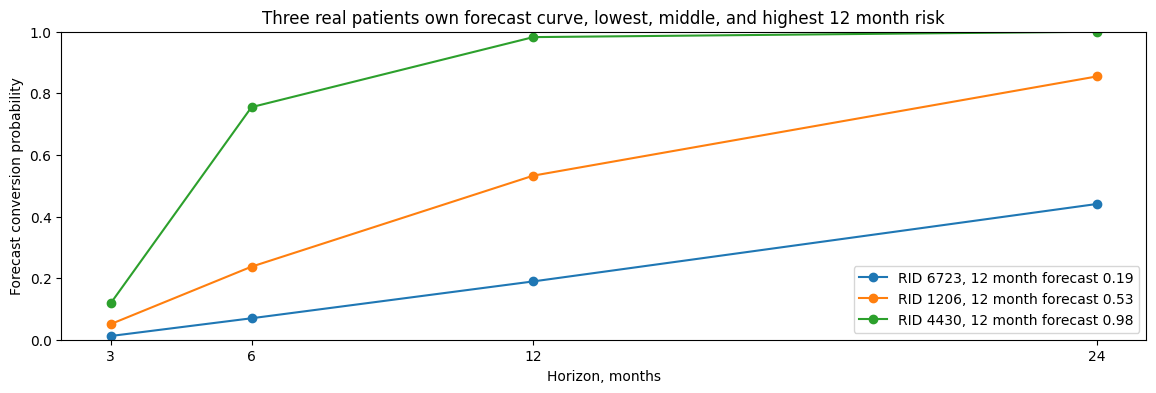

In [5]:
horizons = (3, 6, 12, 24)
real_forecast_train = (
    train_df[train_df['HAS_REAL_FORECAST']]
    .drop_duplicates(subset='RID')
    .sort_values('CONVERSION_PROB_12M')
    .reset_index(drop=True)
)
n_examples = len(real_forecast_train)
example_positions = [0, n_examples // 2, n_examples - 1]
example_rows = real_forecast_train.iloc[example_positions]

plt.figure(figsize=figsize)
for _, row in example_rows.iterrows():
    curve = [row[f'CONVERSION_PROB_{h}M'] for h in horizons]
    plt.plot(horizons, curve, marker='o', label=f"RID {int(row['RID'])}, 12 month forecast {row['CONVERSION_PROB_12M']:.2f}")
plt.xticks(horizons)
plt.ylim(0, 1)
plt.xlabel('Horizon, months')
plt.ylabel('Forecast conversion probability')
plt.title('Three real patients own forecast curve, lowest, middle, and highest 12 month risk')
plt.legend()
plt.show()

Does reading three real numbers instead of one actually spread recommendations out, or collapse them. The panel below answers directly, on the test split's own rows with a real forecast, RECOMMENDED_INTERVAL from this policy against what the snapshot adaptive policy alone would have recommended for those exact same rows, using CONVERSION_PROB_3M as the input, which equals HAZARD_ESTIMATE exactly for these rows, the same single step hazard before any compounding, so the comparison is exact rather than approximate.

hazard_survival_model.ipynb's own section 10 already flags that its area under the ROC curve validates ranking, never calibration, a CONVERSION_PROB_3M of 0.3 is not shown to mean a true 30 percent chance of worsening in the next 3 months. Compounding an uncalibrated per step probability across as many as eight steps to reach 24 months, exactly what the persistence approximation calls for, carries that same uncertainty forward rather than resolving it, so what the panel below actually shows is worth reading as a consequence of that compounding under this notebook's own cost assumptions, not assumed in advance.

Test, 1978 rows with a real forecast
  Forecast adaptive policy,       99.5% get the shortest, 3 month interval
  Snapshot only, same rows,       56.1% get the shortest, 3 month interval
  Mean CONVERSION_PROB_3M among these rows,  0.308
  Mean CONVERSION_PROB_6M among these rows,  0.515
  Mean CONVERSION_PROB_12M among these rows, 0.734


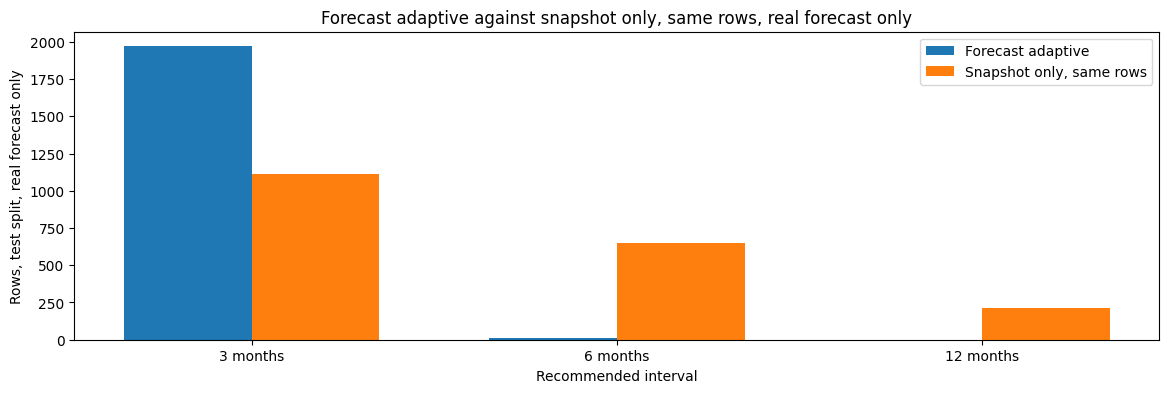

In [6]:
real_forecast_test = test_df[test_df['HAS_REAL_FORECAST']]
snapshot_only_on_forecast_rows = du.recommend_interval(
    real_forecast_test['CONVERSION_PROB_3M'].values, interval_menu_months=(3, 6, 12),
    check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(real_forecast_test),
    reference_interval_months=REFERENCE_INTERVAL_MONTHS,
)
forecast_choice_on_forecast_rows = real_forecast_test['RECOMMENDED_INTERVAL'].values

candidate_menu = (3, 6, 12)
forecast_counts = pd.Series(forecast_choice_on_forecast_rows).value_counts().reindex(candidate_menu, fill_value=0)
snapshot_counts = pd.Series(snapshot_only_on_forecast_rows).value_counts().reindex(candidate_menu, fill_value=0)

print(f'Test, {len(real_forecast_test)} rows with a real forecast')
print(f'  Forecast adaptive policy,       {(forecast_choice_on_forecast_rows == 3).mean() * 100:.1f}% get the shortest, 3 month interval')
print(f'  Snapshot only, same rows,       {(snapshot_only_on_forecast_rows == 3).mean() * 100:.1f}% get the shortest, 3 month interval')
print(f'  Mean CONVERSION_PROB_3M among these rows,  {real_forecast_test["CONVERSION_PROB_3M"].mean():.3f}')
print(f'  Mean CONVERSION_PROB_6M among these rows,  {real_forecast_test["CONVERSION_PROB_6M"].mean():.3f}')
print(f'  Mean CONVERSION_PROB_12M among these rows, {real_forecast_test["CONVERSION_PROB_12M"].mean():.3f}')

bar_x = np.arange(len(candidate_menu))
bar_width = 0.35
plt.figure(figsize=figsize)
plt.bar(bar_x - bar_width / 2, forecast_counts.values, bar_width, label='Forecast adaptive')
plt.bar(bar_x + bar_width / 2, snapshot_counts.values, bar_width, label='Snapshot only, same rows')
plt.xticks(bar_x, [f'{month} months' for month in candidate_menu])
plt.xlabel('Recommended interval')
plt.ylabel('Rows, test split, real forecast only')
plt.title('Forecast adaptive against snapshot only, same rows, real forecast only')
plt.legend()
plt.show()

<a id="sec5"></a>

## 5. Checking Against Real Outcomes

Every number so far, total cost, the forecast curve above, is a function of the cost formula and the forecast columns alone, nothing yet has checked what actually happened to a real patient outside of the training rows the hazard estimator behind those columns already fit on. final.csv already records DIAGNOSIS at every visit, so compute_diagnosis_worsening below finds, for every row, that same patient's next real recorded visit and whether DIAGNOSIS was numerically worse there, a real worsening event, checked here directly against RECOMMENDED_INTERVAL. The hazard estimator behind CONVERSION_PROB_3M, CONVERSION_PROB_6M, and CONVERSION_PROB_12M was fit only on training patients, so the check below is genuinely held out on the test split, on train the same rows are being checked against an estimator that already saw their own outcome while fitting, exactly why the two splits are read separately below rather than pooled into one number.

For every row with a real worsening event, the margin below is the real gap in months to that next visit minus RECOMMENDED_INTERVAL, this row's own forecast adaptive choice from section 4. A positive margin means a check on this policy's own schedule would have happened at or before the real worsening was ever observed, caught in time, a negative one means this row's chosen interval would have left the patient unchecked for longer than the real world actually took to reveal it.

This is retrospective, not a true counterfactual, ADNI's actual visit spacing was never governed by this or any other policy under test here, and it should be read together with the total cost above, not in isolation, since a policy that always recommended the shortest possible interval would trivially win this check alone while being far too expensive to ever deploy.

Train, 501 rows with a real worsening event before the next recorded visit, 86.2 percent would have been caught by this policy in time.
Test, 197 rows with a real worsening event before the next recorded visit, 91.4 percent would have been caught by this policy in time.


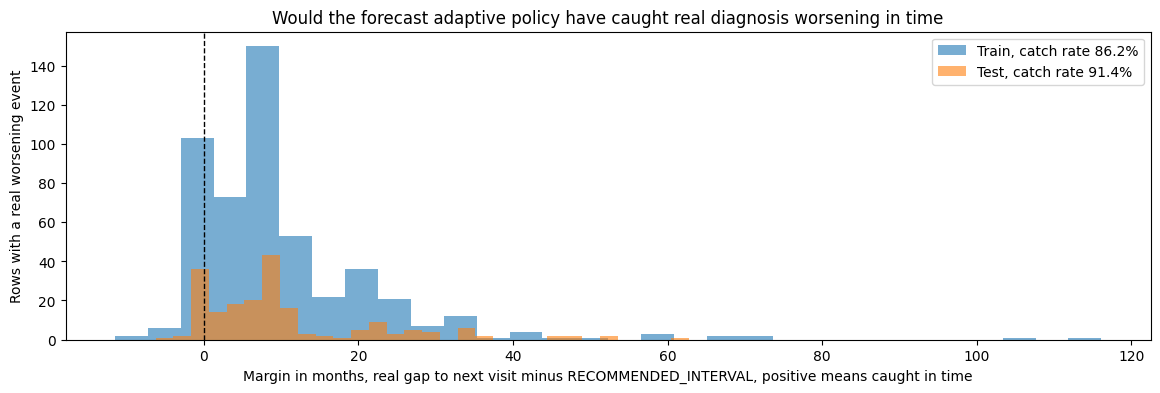

In [7]:
def catch_rate_report(df, label, recommended):
    outcomes = du.compute_diagnosis_worsening(df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    catch_rate = (margin >= 0).mean() * 100
    print(f'{label}, {worsened.sum()} rows with a real worsening event before the next recorded visit, '
          f'{catch_rate:.1f} percent would have been caught by this policy in time.')
    return margin, catch_rate

train_margin, train_catch_rate = catch_rate_report(train_df, 'Train', train_df['RECOMMENDED_INTERVAL'].values)
test_margin, test_catch_rate = catch_rate_report(test_df, 'Test', test_df['RECOMMENDED_INTERVAL'].values)

plt.figure(figsize=figsize)
plt.hist(train_margin, bins=30, alpha=0.6, label=f'Train, catch rate {train_catch_rate:.1f}%')
plt.hist(test_margin, bins=30, alpha=0.6, label=f'Test, catch rate {test_catch_rate:.1f}%')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Margin in months, real gap to next visit minus RECOMMENDED_INTERVAL, positive means caught in time')
plt.ylabel('Rows with a real worsening event')
plt.title('Would the forecast adaptive policy have caught real diagnosis worsening in time')
plt.legend()
plt.show()

<a id="sec6"></a>

## 6. Fairness Check

DIDI, the Disparate Impact Discrimination Index from 07 ciml, lesson 1, measures how much a recommendation differs on average between a protected group and the rest, summed over every protected attribute checked, here PTGENDER, a bucketed PTEDUCAT, and PTMARRY. RECOMMENDED_INTERVAL here can vary for a genuinely different reason than in any other notebook in this folder, a real multi horizon forecast rather than one number, so this check is asking whether that richer input leaves any average difference between groups behind.

In [8]:
def make_protected(df):
    return {
        'PTGENDER': (1, 2),
        'PTEDUCAT_BUCKET': (0, 1),
        'PTMARRY': tuple(sorted(df['PTMARRY'].dropna().unique())),
    }

train_df = train_df.copy()
test_df = test_df.copy()
train_df['PTEDUCAT_BUCKET'] = du.bucket_educat(train_df['PTEDUCAT'], split_at=16)
test_df['PTEDUCAT_BUCKET'] = du.bucket_educat(test_df['PTEDUCAT'], split_at=16)

train_didi = du.compute_didi(train_df, train_df['RECOMMENDED_INTERVAL'].values, make_protected(train_df))
test_didi = du.compute_didi(test_df, test_df['RECOMMENDED_INTERVAL'].values, make_protected(test_df))
print(f'DIDI on the recommended interval, train: {train_didi:.3f}')
print(f'DIDI on the recommended interval, test:  {test_didi:.3f}')

DIDI on the recommended interval, train: 7.450
DIDI on the recommended interval, test:  8.516


<a id="sec7"></a>

## 7. How Much Would These Numbers Move

Every number above, total cost, DIDI, catch rate, comes from one fixed sample of patients, the actual train and test split. A different, equally valid sample of ADNI patients would give a slightly different number, bootstrap_ci below answers by how much, resample patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, recompute the same metric on each resample, and read the 2.5th and 97.5th percentile as a 95 percent interval. The histograms below are the full bootstrap distribution behind each interval, not only its two endpoints.

Wide or narrow, this interval says nothing about whether the number is good, only how much of it is signal against a different sample versus noise from this particular one, useful together with the comparison against the other three policies, not instead of it.

Train, total cost 101932.9, 95% CI [95786.9, 108647.3]
Test,  total cost 38795.6, 95% CI [34791.9, 42798.1]
Train, catch rate 86.2%, 95% CI [83.0, 89.4]
Test,  catch rate 91.4%, 95% CI [87.4, 95.1]


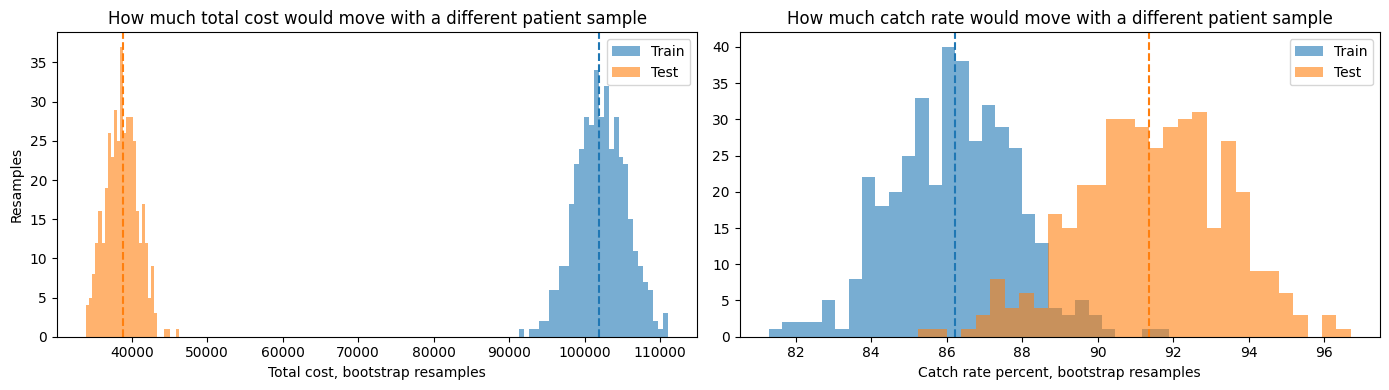

In [9]:
def get_recommended(d):
    forecast_df = d[['CONVERSION_PROB_3M', 'CONVERSION_PROB_6M', 'CONVERSION_PROB_12M']]
    recommended, chosen_probability = du.recommend_interval_forecast(
        forecast_df, interval_menu_months=(3, 6, 12), check_cost=CHECK_COST,
        missed_conversion_cost=missed_conversion_cost_for(d),
    )
    return recommended, chosen_probability

def cost_metric(d):
    recommended, chosen_probability = get_recommended(d)
    total_cost, _, _ = cost_model_for(d).cost_from_forecast(
        rid_ids=d['RID'].values, horizon_probabilities=chosen_probability,
        threshold=0.5, interval_months=recommended, return_margin=False,
    )
    return total_cost

def didi_metric(d):
    recommended, _ = get_recommended(d)
    d = d.copy()
    d['PTEDUCAT_BUCKET'] = du.bucket_educat(d['PTEDUCAT'], split_at=16)
    return du.compute_didi(d, recommended, make_protected(d))

def catch_rate_metric(d):
    recommended, _ = get_recommended(d)
    outcomes = du.compute_diagnosis_worsening(d, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    return (margin >= 0).mean() * 100

train_cost_point, train_cost_lo, train_cost_hi, train_cost_samples = du.bootstrap_ci(train_df, cost_metric, id_col='RID')
test_cost_point, test_cost_lo, test_cost_hi, test_cost_samples = du.bootstrap_ci(test_df, cost_metric, id_col='RID')
train_didi_point, train_didi_lo, train_didi_hi, _ = du.bootstrap_ci(train_df, didi_metric, id_col='RID')
test_didi_point, test_didi_lo, test_didi_hi, _ = du.bootstrap_ci(test_df, didi_metric, id_col='RID')
train_catch_point, train_catch_lo, train_catch_hi, train_catch_samples = du.bootstrap_ci(train_df, catch_rate_metric, id_col='RID')
test_catch_point, test_catch_lo, test_catch_hi, test_catch_samples = du.bootstrap_ci(test_df, catch_rate_metric, id_col='RID')

print(f'Train, total cost {train_cost_point:.1f}, 95% CI [{train_cost_lo:.1f}, {train_cost_hi:.1f}]')
print(f'Test,  total cost {test_cost_point:.1f}, 95% CI [{test_cost_lo:.1f}, {test_cost_hi:.1f}]')
print(f'Train, catch rate {train_catch_point:.1f}%, 95% CI [{train_catch_lo:.1f}, {train_catch_hi:.1f}]')
print(f'Test,  catch rate {test_catch_point:.1f}%, 95% CI [{test_catch_lo:.1f}, {test_catch_hi:.1f}]')

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(train_cost_samples, bins=30, alpha=0.6, label='Train')
axes[0].hist(test_cost_samples, bins=30, alpha=0.6, label='Test')
axes[0].axvline(train_cost_point, color='C0', linestyle='--')
axes[0].axvline(test_cost_point, color='C1', linestyle='--')
axes[0].set_xlabel('Total cost, bootstrap resamples')
axes[0].set_ylabel('Resamples')
axes[0].set_title('How much total cost would move with a different patient sample')
axes[0].legend()

axes[1].hist(train_catch_samples, bins=30, alpha=0.6, label='Train')
axes[1].hist(test_catch_samples, bins=30, alpha=0.6, label='Test')
axes[1].axvline(train_catch_point, color='C0', linestyle='--')
axes[1].axvline(test_catch_point, color='C1', linestyle='--')
axes[1].set_xlabel('Catch rate percent, bootstrap resamples')
axes[1].set_title('How much catch rate would move with a different patient sample')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="sec8"></a>

## 8. Saving The Standardized Result

One row per split, appended to the shared results/decision_support/approach_comparison.csv, read later by comparison.ipynb alongside the other three interval policies. The notes column for this approach records the real forecast coverage percent for that split, since that number matters for reading the result correctly, exactly as coverage is recorded for the other two richer policies. append_approach_result is idempotent per approach and split, rerunning this notebook replaces its own two rows rather than piling up duplicates. The confidence intervals from the section above ride along in the same row.

In [10]:
train_notes = f'Reads the real multi horizon forecast when available, {train_coverage:.1f} percent of train rows, the rest fall back to the snapshot risk score scaled by horizon.'
test_notes = f'Reads the real multi horizon forecast when available, {test_coverage:.1f} percent of test rows, the rest fall back to the snapshot risk score scaled by horizon.'

du.append_approach_result(
    results_path, approach='forecast_adaptive', approach_group='interval_policy',
    split='train', n_rows=len(train_df), total_cost=train_total_cost,
    over_threshold_count=train_over_threshold, didi=train_didi,
    catch_rate=train_catch_rate,
    ci={
        'total_cost': (train_cost_lo, train_cost_hi),
        'didi': (train_didi_lo, train_didi_hi),
        'catch_rate': (train_catch_lo, train_catch_hi),
    },
    notes=train_notes,
)
result_row = du.append_approach_result(
    results_path, approach='forecast_adaptive', approach_group='interval_policy',
    split='test', n_rows=len(test_df), total_cost=test_total_cost,
    over_threshold_count=test_over_threshold, didi=test_didi,
    catch_rate=test_catch_rate,
    ci={
        'total_cost': (test_cost_lo, test_cost_hi),
        'didi': (test_didi_lo, test_didi_hi),
        'catch_rate': (test_catch_lo, test_catch_hi),
    },
    notes=test_notes,
)
result_row

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
6,pipeline_health_index,interval_policy,train,10162,59644.077200,4837.0,2.930656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
7,pipeline_health_index,interval_policy,test,3665,21640.887371,1752.0,2.029942,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
8,hazard_logistic_core,hazard_model,train,6415,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, logistic, core..."
9,hazard_logistic_core,hazard_model,test,2291,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704754,0.782472,"Discrete time hazard estimator, logistic, core..."


<a id="sec9"></a>

## 9. How Sensitive Is This To The Exact Cost Ratio

Section 3 already flagged that MCI_OR_WORSE_COST_MULTIPLIER, set to 2.8, is a single point estimate sitting inside a documented range that runs from about 1.4 to about 4 depending on the study. recommend_interval_forecast uses that multiplier directly when it chooses an interval, exactly as the other two adaptive policies already do, so a different multiplier can change RECOMMENDED_INTERVAL itself, not only how expensive the outcome looks afterward.

The cell below reruns this notebook's own interval choice at 1.5, at 2.8, and at 4.0, holding every other setting fixed, and reports total_cost and catch_rate at each one, on both splits, saved to cost_sensitivity_forecast_adaptive.csv for comparison.ipynb to read alongside the other three policies.

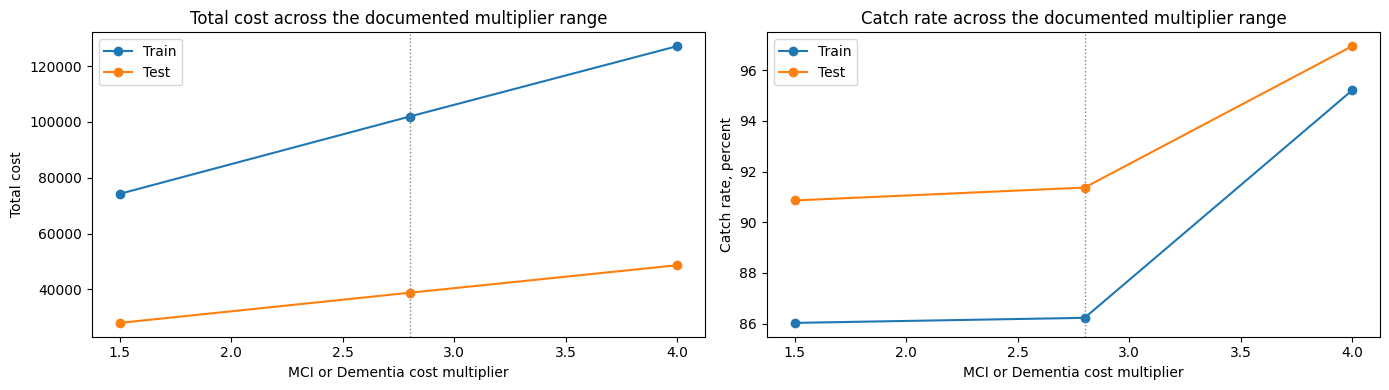

,multiplier,approach,train_total_cost,test_total_cost,train_catch_rate,test_catch_rate
0,1.5,forecast_adaptive,74241.107223,28001.631618,86.027944,90.862944
1,2.8,forecast_adaptive,101932.943304,38795.602863,86.227545,91.370558
2,4.0,forecast_adaptive,127154.938412,48662.273227,95.209581,96.954315


In [11]:
SENSITIVITY_MULTIPLIERS = (1.5, 2.8, 4.0)

def sensitivity_at(df, multiplier):
    forecast_df = df[['CONVERSION_PROB_3M', 'CONVERSION_PROB_6M', 'CONVERSION_PROB_12M']]
    recommended, chosen_probability = du.recommend_interval_forecast(
        forecast_df, interval_menu_months=(3, 6, 12), check_cost=CHECK_COST,
        missed_conversion_cost=missed_conversion_cost_for(df, multiplier=multiplier),
    )
    total_cost, _, _ = cost_model_for(df, multiplier=multiplier).cost_from_forecast(
        rid_ids=df['RID'].values, horizon_probabilities=chosen_probability,
        threshold=0.5, interval_months=recommended, return_margin=False,
    )
    outcomes = du.compute_diagnosis_worsening(df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    catch_rate = (margin >= 0).mean() * 100
    return total_cost, catch_rate

sensitivity_rows = []
for multiplier in SENSITIVITY_MULTIPLIERS:
    train_cost, train_catch = sensitivity_at(train_df, multiplier)
    test_cost, test_catch = sensitivity_at(test_df, multiplier)
    sensitivity_rows.append({
        'multiplier': multiplier,
        'approach': 'forecast_adaptive',
        'train_total_cost': train_cost,
        'test_total_cost': test_cost,
        'train_catch_rate': train_catch,
        'test_catch_rate': test_catch,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(os.path.join(results_path, 'cost_sensitivity_forecast_adaptive.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=figsize)
axes[0].plot(sensitivity_df['multiplier'], sensitivity_df['train_total_cost'], marker='o', label='Train')
axes[0].plot(sensitivity_df['multiplier'], sensitivity_df['test_total_cost'], marker='o', label='Test')
axes[0].axvline(MCI_OR_WORSE_COST_MULTIPLIER, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('MCI or Dementia cost multiplier')
axes[0].set_ylabel('Total cost')
axes[0].set_title('Total cost across the documented multiplier range')
axes[0].legend()

axes[1].plot(sensitivity_df['multiplier'], sensitivity_df['train_catch_rate'], marker='o', label='Train')
axes[1].plot(sensitivity_df['multiplier'], sensitivity_df['test_catch_rate'], marker='o', label='Test')
axes[1].axvline(MCI_OR_WORSE_COST_MULTIPLIER, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('MCI or Dementia cost multiplier')
axes[1].set_ylabel('Catch rate, percent')
axes[1].set_title('Catch rate across the documented multiplier range')
axes[1].legend()

plt.tight_layout()
plt.show()

sensitivity_df

<a id="sec10"></a>

## 10. Takeaways

**Read this notebook's own numbers above as this approach's result on its own, then see comparison.ipynb for how it stacks up against the other three interval policies, with one caveat that matters more here than anywhere else in this folder.** Total cost above is not on the same scale as fixed_policy, snapshot_adaptive, or trajectory_adaptive's own total cost, because cost_from_forecast prices a genuinely different, and structurally larger, quantity, a real compounded conversion probability rather than one snapshot linearly scaled down for a shorter interval. A lower number in the other three notebooks does not mean a cheaper real policy, it may mean their own approximation understates cumulative risk at longer horizons, exactly the gap this notebook was built to close, so the total cost figures across all four are testing four different pricing assumptions, not one shared quantity that can be range compared directly.

Section 4 above already shows the sharper version of that same point, this policy recommends the shortest, 3 month interval for nearly every row with a real forecast, where the snapshot policy spreads the identical rows across all three candidates. That collapse follows directly from how large CONVERSION_PROB_3M and CONVERSION_PROB_6M already average among these rows, high enough that the shortest interval rarely loses under this notebook's own cost assumptions, and from hazard_survival_model.ipynb's own stated limitation, its area under the ROC curve validates ranking, never calibration, so a probability compounded across up to eight future steps carries that same uncertainty forward rather than resolving it. Read together, this policy's higher catch rate above sits closer to what checking almost everyone every 3 months would already buy than to a demonstration that a richer forecast chooses a more varied, better targeted schedule.

Coverage is the second limit, identical in shape to the other two richer policies. For the rows without a real forecast, CONVERSION_PROB_3M, CONVERSION_PROB_6M, and CONVERSION_PROB_12M are all derived from the one FALLBACK_RISK_SCORE by the same fixed scaling recommend_interval itself already applies, so this policy's real advantage is concentrated in just over half the rows, and is mathematically identical to the snapshot adaptive policy for the rest.

Last, this notebook, like the other three, is still Predict then Optimize, a small fixed menu searched against a documented cost assumption, not a policy learned end to end against real historical outcomes, ADNI simply does not record the kind of decision and outcome pairs a genuine Decision Focused Learning objective would need.